# Oracle search algorithms: Grover

Grover searches for a marked element among `N` unsorted elements, with a quadratic advantage over any classical search: where classically on the order of `N` oracle queries are needed, Grover needs on the order of `√N`. This notebook builds the smallest case with a real advantage: 2 qubits, 4 elements, solved with a single iteration.

## Grover's oracle

Unlike the Deutsch-Jozsa oracle, which accumulates `f(x)` on an auxiliary qubit, Grover's oracle marks the sought element directly with a phase flip, with no auxiliary qubit: `|x⟩ → -|x⟩` if `x` is the marked element, `|x⟩ → |x⟩` otherwise.

To mark `|11⟩` with 2 qubits, that gate is exactly CZ: it flips the phase only when both qubits are 1.

## The diffuser

Marking the element is not enough: its amplitude is still small, indistinguishable when measured. The diffuser inverts every amplitude about their mean, which increases the marked element's and reduces the rest. It is built with H, X, and the phase-marking gate again, this time applied to `|00⟩` instead of to the sought element.

In [1]:
import polypus

qc = polypus.Circuit(2)
qc.h(0)
qc.h(1)  # uniform superposition over the 4 elements

qc.cz(0, 1)  # oracle: marks |11>

qc.h(0)  # diffuser
qc.h(1)
qc.x(0)
qc.x(1)
qc.cz(0, 1)
qc.x(0)
qc.x(1)
qc.h(0)
qc.h(1)

qc.measure_all()

Circuit(num_qubits=2, num_params=0, gates=13)

With the pattern seen in [`02b`](02b_qiskit_qasm_interop.ipynb):

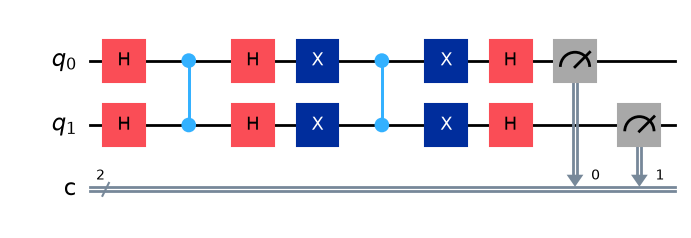

In [2]:
from qiskit import qasm2

qc_drawing = qasm2.loads(
    qc.to_qasm2(), custom_instructions=qasm2.LEGACY_CUSTOM_INSTRUCTIONS
)
qc_drawing.draw("mpl")

In [3]:
result = polypus.run_quantum_circuit(qc, shots=1000, infrastructure="local")
print(result.counts[0])

{'11': 1000}


The result is `'11'` 100% of the time: with a single iteration of oracle plus diffuser, and 4 possible elements, Grover finds the marked one with certainty. With more elements, more iterations are needed, and it stops being an exact certainty and becomes a very high probability instead.

## Beyond 2 qubits

Grover's oracle and diffuser for more than 2 qubits need a multi-controlled Z gate, which flips the phase only when every control qubit is 1 at once. There are two ways to get one in Polypus.

The first is decomposing a Toffoli, a 2-qubit control over a third one, into 1- and 2-qubit primitives: it is written with H, T, Tdg, and CX. It is worth seeing even though a more direct alternative exists, because it is the classic construction and it explains why T, seen in [`02a`](02a_gates_and_circuits.ipynb), reappears here:

In [4]:
def decomposed_ccx(qc, a, b, c):
    qc.h(c)
    qc.cx(b, c)
    qc.tdg(c)
    qc.cx(a, c)
    qc.t(c)
    qc.cx(b, c)
    qc.tdg(c)
    qc.cx(a, c)
    qc.t(b)
    qc.t(c)
    qc.cx(a, b)
    qc.h(c)
    qc.t(a)
    qc.tdg(b)
    qc.cx(a, b)

It is checked the same way as any other gate, against the four input combinations of a real Toffoli:

In [5]:
for a_val in (0, 1):
    for b_val in (0, 1):
        test_qc = polypus.Circuit(3)
        if a_val:
            test_qc.x(0)
        if b_val:
            test_qc.x(1)
        decomposed_ccx(test_qc, 0, 1, 2)
        test_qc.measure_all()
        result = polypus.run_quantum_circuit(test_qc, shots=200, infrastructure="local")
        print(f"a={a_val} b={b_val} ->", result.counts[0])

a=0 b=0 -> {'000': 200}
a=0 b=1 -> {'010': 200}
a=1 b=0 -> {'001': 200}
a=1 b=1 -> {'111': 200}


Qubit `c` only flips when `a` and `b` are both 1 at once, exactly the behavior of a Toffoli.

The second alternative is the native `ccx` gate, which does the same thing directly, with no decomposition. Polypus also has `c3x` and `c4x` for 3 and 4 controls, if more were needed:

In [6]:
native_qc = polypus.Circuit(3)
native_qc.x(0)
native_qc.x(1)
native_qc.ccx(0, 1, 2)
native_qc.measure_all()

result = polypus.run_quantum_circuit(native_qc, shots=200, infrastructure="local")
print(result.counts[0])

{'111': 200}


The result is identical to the decomposition's: `'111'`, with `a=1` and `b=1`.

## Summary

This notebook built Grover for 2 qubits, finding the marked element with a single iteration and full certainty, and showed the two ways to extend the oracle and the diffuser beyond 2 qubits: decomposing a Toffoli by hand with H, T, Tdg, and CX, seeing what it is made of inside, or using the native `ccx` gate directly (and `c3x`/`c4x` for more controls).

The next section trains parameterized circuits with data, starting with QAOA on the MaxCut problem.

## Next step

Continue with: [`06a_variational_training.ipynb`](06a_variational_training.ipynb).